# 03 — Customer LTV: BG/NBD + Gamma-Gamma

Probabilistic customer lifetime value — the industry standard for e-commerce.

**Contents:**
1. RFM distributions
2. BG/NBD model — purchase frequency + P(alive)
3. Gamma-Gamma — expected monetary value
4. LTV predictions and segments
5. Cohort retention analysis

In [13]:
import sys, os
# Make project root importable regardless of where Jupyter is launched from
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
print("Project root added to path ✓")

Project root added to path ✓


=== Expected Purchases — Frequency × Recency ===


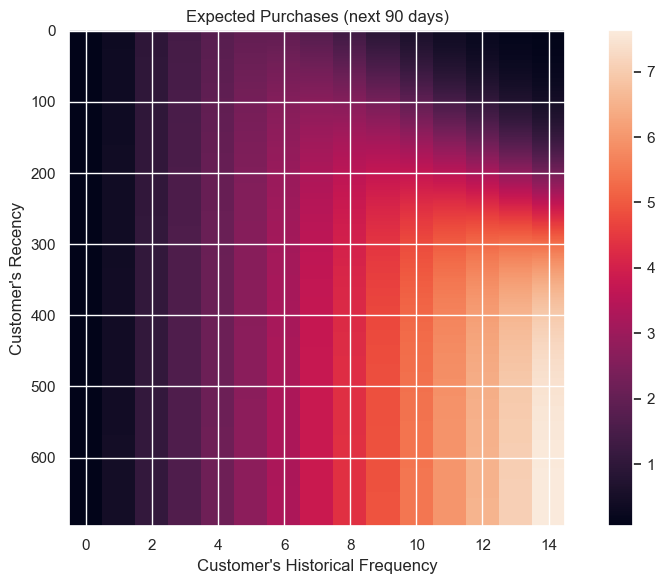

=== P(Alive) — Frequency × Recency ===


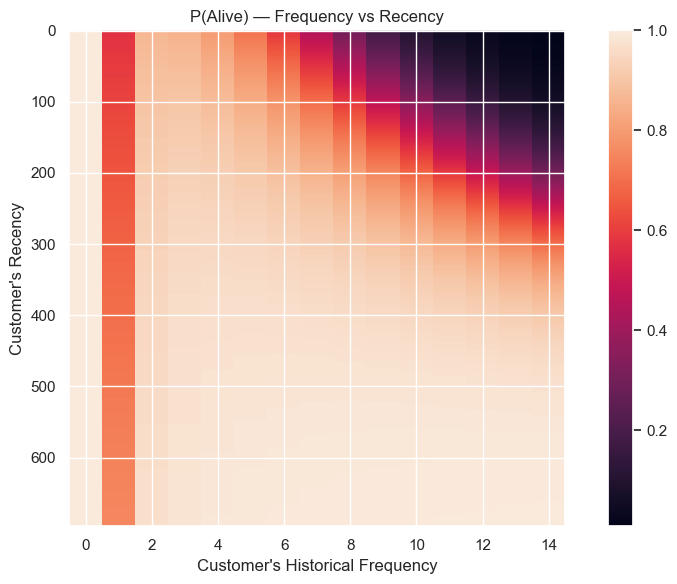

Median P(alive): 100.0%
Customers with P(alive) > 50%: 93,356


In [14]:
# lifetimes plotting functions always create their own figure internally.
# The only reliable way to show both side-by-side is to render each into
# its own figure, then display sequentially.

print("=== Expected Purchases — Frequency × Recency ===")
fig1 = plt.figure(figsize=(9, 6))
plot_frequency_recency_matrix(ltv_model.bgf, T=rfm["T_days"].max())
plt.title("Expected Purchases (next 90 days)")
plt.tight_layout()
plt.show()

print("=== P(Alive) — Frequency × Recency ===")
fig2 = plt.figure(figsize=(9, 6))
plot_probability_alive_matrix(ltv_model.bgf)
plt.title("P(Alive) — Frequency vs Recency")
plt.tight_layout()
plt.show()

print(f"Median P(alive): {predictions['p_alive'].median():.1%}")
print(f"Customers with P(alive) > 50%: {(predictions['p_alive'] > 0.5).sum():,}")

## 1. RFM Distributions

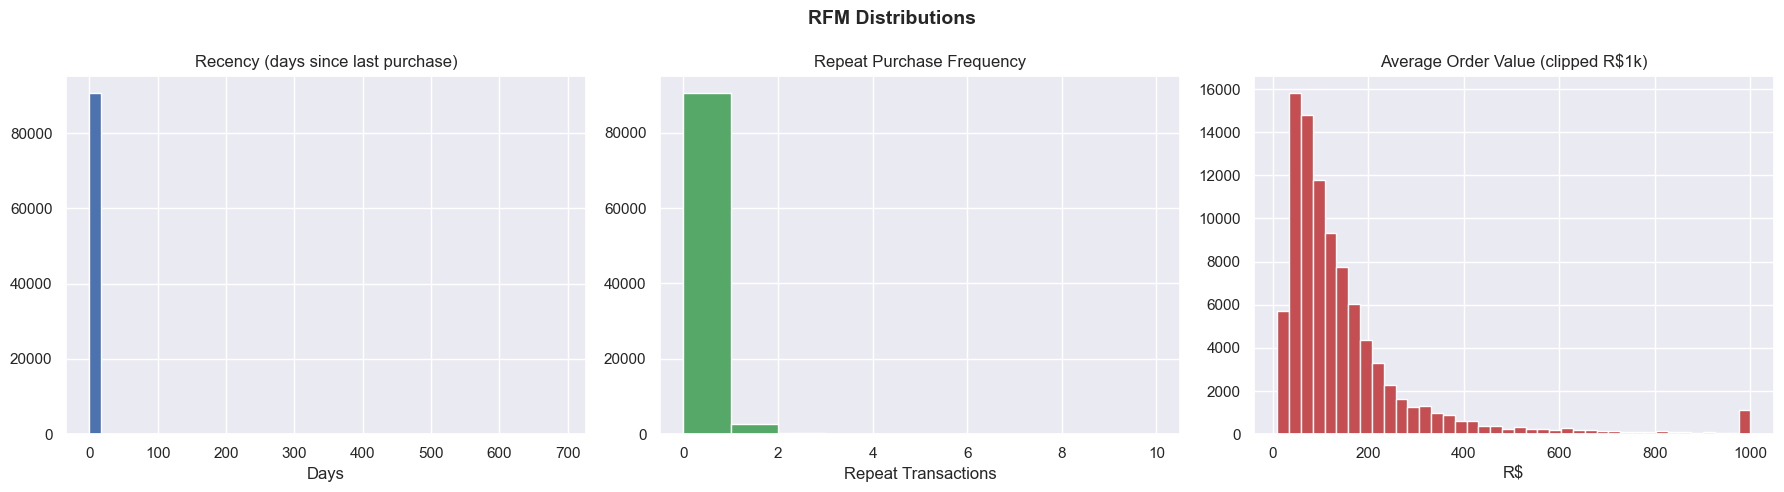

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(rfm["recency_days"], bins=40, color="#4C72B0", edgecolor="white")
axes[0].set_title("Recency (days since last purchase)")
axes[0].set_xlabel("Days")

axes[1].hist(rfm["frequency_repeat"].clip(0, 10), bins=10, color="#55A868", edgecolor="white")
axes[1].set_title("Repeat Purchase Frequency")
axes[1].set_xlabel("Repeat Transactions")

axes[2].hist(rfm["monetary_mean"].clip(0, 1000), bins=40, color="#C44E52", edgecolor="white")
axes[2].set_title("Average Order Value (clipped R$1k)")
axes[2].set_xlabel("R$")

plt.suptitle("RFM Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 2. Train BG/NBD + Gamma-Gamma

In [16]:

ltv_model   = CustomerLTVModel()
predictions = ltv_model.train_and_predict(rfm, predict_days=[90, 365])

print(predictions[[
    "customer_unique_id", "p_alive",
    "predicted_ltv_90d", "predicted_ltv_365d",
    "clv_12m", "ltv_segment"
]].head(10).to_string(index=False))

2026-03-06 21:00:54.211 | INFO     | ml.customer_ltv_model:_validate:228 - Valid RFM rows: 93,357
2026-03-06 21:00:58.482 | INFO     | ml.customer_ltv_model:train_and_predict:102 - BG/NBD fitted ✓
2026-03-06 21:00:58.483 | INFO     | ml.customer_ltv_model:train_and_predict:103 -   r=0.0955  α=608.1726  a=0.0350  b=0.1083
2026-03-06 21:00:58.560 | INFO     | ml.customer_ltv_model:train_and_predict:116 - Gamma-Gamma fitted ✓
2026-03-06 21:00:58.561 | INFO     | ml.customer_ltv_model:train_and_predict:117 -   p=11.2240  q=1.4761  v=10.4843
2026-03-06 21:00:59.804 | WARNING  | ml.customer_ltv_model:_evaluate:265 - Holdout evaluation failed: The column label 'customer_id' is not unique.
2026-03-06 21:01:00.282 | INFO     | ml.customer_ltv_model:_write_seed:282 - LTV seed written → dbt_project\seeds\ltv_predictions.csv  (93,357 rows)
2026-03-06 21:01:00.292 | INFO     | ml.customer_ltv_model:train_and_predict:185 - LTV predictions complete — 93,357 customers
  Median 90d LTV:  R$ 2.55
  Medi

🏃 View run customer_ltv_bgnbd at: http://localhost:5000/#/experiments/2/runs/7386c9809591453d89d81509a61b0d94
🧪 View experiment at: http://localhost:5000/#/experiments/2
              customer_unique_id  p_alive  predicted_ltv_90d  predicted_ltv_365d  clv_12m ltv_segment
0000366f3b9a7992bf8c76cfdf3221e2    1.000              2.905              11.346   10.511        Gold
0000b849f77a49e4a4ce2b2a4ca5be3f    1.000              2.893              11.301   10.470        Gold
0000f46a3911fa3c0805444483337064    1.000              1.837               7.257    6.721      Bronze
0000f6ccb0745a6a4b88665a16c9f078    1.000              2.259               8.882    8.227      Silver
0004aac84e0df4da2b147fca70cf8255    1.000              2.341               9.197    8.519      Silver
0004bd2a26a76fe21f786e4fbd80607f    1.000              2.776              10.855   10.056        Gold
00050ab1314c0e55a6ca13cf7181fecf    1.000              2.827              11.052   10.239        Gold
00053a61a98854

## 3. P(Alive) — Frequency vs Recency Matrix

=== Expected Purchases — Frequency × Recency ===


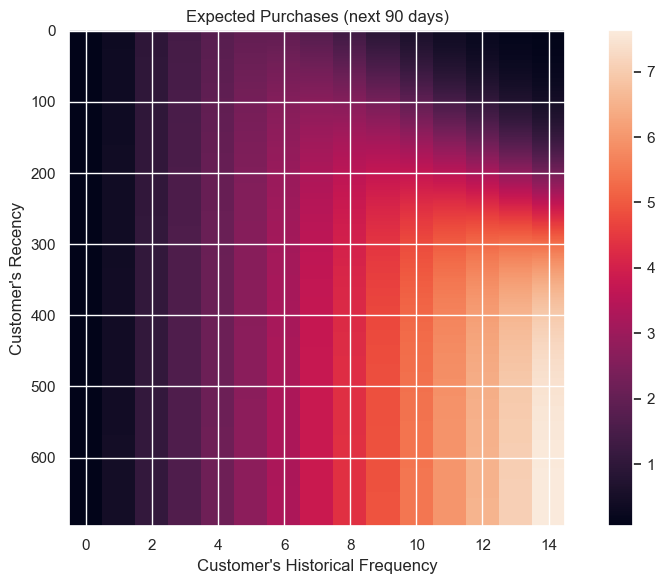

=== P(Alive) — Frequency × Recency ===


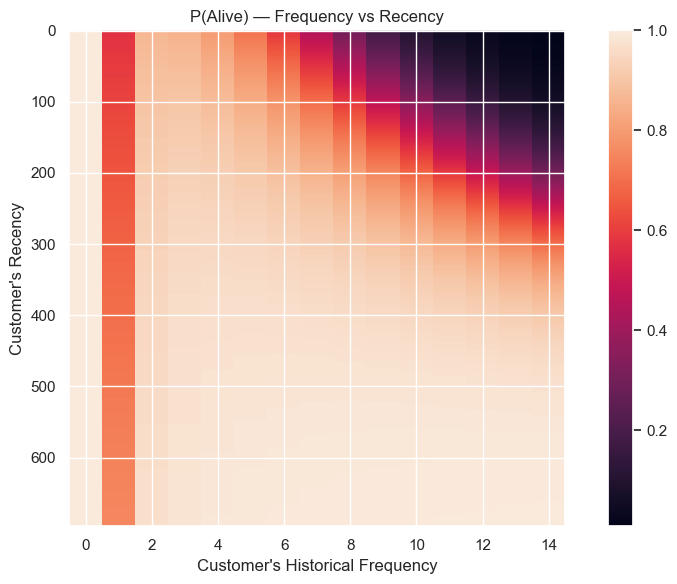

Median P(alive): 100.0%
Customers with P(alive) > 50%: 93,356


In [17]:
# lifetimes plotting functions always create their own figure internally.
# The only reliable way to show both side-by-side is to render each into
# its own figure, then display sequentially.

print("=== Expected Purchases — Frequency × Recency ===")
fig1 = plt.figure(figsize=(9, 6))
plot_frequency_recency_matrix(ltv_model.bgf, T=rfm["T_days"].max())
plt.title("Expected Purchases (next 90 days)")
plt.tight_layout()
plt.show()

print("=== P(Alive) — Frequency × Recency ===")
fig2 = plt.figure(figsize=(9, 6))
plot_probability_alive_matrix(ltv_model.bgf)
plt.title("P(Alive) — Frequency vs Recency")
plt.tight_layout()
plt.show()

print(f"Median P(alive): {predictions['p_alive'].median():.1%}")
print(f"Customers with P(alive) > 50%: {(predictions['p_alive'] > 0.5).sum():,}")

## 4. LTV Segments

In [18]:
seg = ltv_model.segment_summary(predictions)
print(seg.to_string(index=False))

fig = px.scatter(
    predictions.sample(min(5000, len(predictions)), random_state=42),
    x="predicted_purchases_90d",
    y="predicted_ltv_365d",
    color="ltv_segment",
    size="clv_12m",
    hover_data=["customer_unique_id", "p_alive"],
    title="Customer LTV Landscape — 365d LTV vs Predicted Purchases",
    labels={"predicted_purchases_90d": "Predicted Purchases (90d)",
            "predicted_ltv_365d": "Predicted LTV 365d (R$)"},
    opacity=0.6,
)
fig.show()

ltv_segment  customer_count  avg_p_alive  avg_ltv_365d  total_predicted_revenue  avg_purchases_90d
   Platinum           23199        0.970        17.690               410405.740              0.020
       Gold           23476        1.000        10.700               251268.980              0.010
     Silver           23229        1.000         9.380               217787.880              0.010
     Bronze           23453        1.000         7.880               184771.410              0.010


## 5. Cohort Retention Analysis

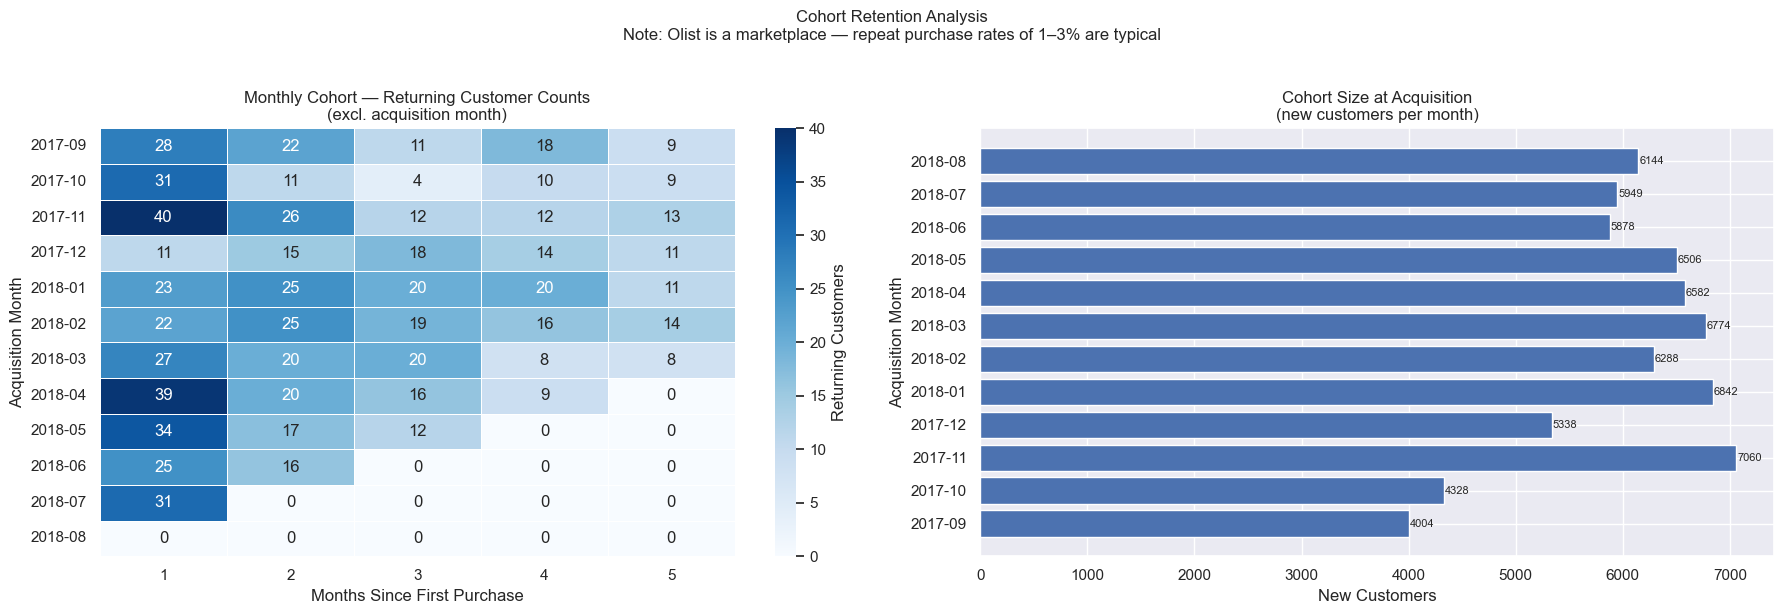

Overall repeat purchase rate: 3.0%
Total unique customers: 93,358
Customers with 2+ orders: 2,801


In [19]:
df = loader.order_features()
df = df[df["order_status"] == "delivered"].copy()

# Olist is a marketplace (~97% one-time buyers) so quarterly cohorts show
# near-zero retention and look empty. Monthly cohorts + absolute counts
# tell a clearer story: how many customers from each cohort came back.
df["cohort"] = (
    df.groupby("customer_unique_id")["order_purchase_timestamp"]
    .transform("min")
    .dt.to_period("M")
)
df["period"] = df["order_purchase_timestamp"].dt.to_period("M")

cohort_data = (
    df.groupby(["cohort", "period"])["customer_unique_id"]
    .nunique().reset_index()
)
cohort_data["period_offset"] = (
    cohort_data["period"] - cohort_data["cohort"]
).apply(lambda x: x.n)

cohort_pivot = cohort_data.pivot_table(
    index="cohort", columns="period_offset", values="customer_unique_id"
)

# Show absolute return counts (not % — retention is genuinely ~1-3% for
# a marketplace, so percentages just render as all-zeros)
cohort_counts = cohort_pivot.fillna(0).astype(int)

# Only show months 0-5 and most recent 12 cohorts for readability
cohort_display = cohort_counts.iloc[-12:, :6]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Left: absolute return counts
sns.heatmap(
    cohort_display.iloc[:, 1:],   # skip month-0 (acquisition)
    annot=True, fmt="d",
    cmap="Blues", linewidths=0.5,
    cbar_kws={"label": "Returning Customers"},
    ax=axes[0],
)
axes[0].set_title("Monthly Cohort — Returning Customer Counts\n(excl. acquisition month)")
axes[0].set_xlabel("Months Since First Purchase")
axes[0].set_ylabel("Acquisition Month")

# Right: acquisition size (month 0) as context
acq = cohort_counts.iloc[-12:, 0].sort_index()
axes[1].barh(acq.index.astype(str), acq.values, color="#4C72B0")
axes[1].set_title("Cohort Size at Acquisition\n(new customers per month)")
axes[1].set_xlabel("New Customers")
axes[1].set_ylabel("Acquisition Month")
for i, v in enumerate(acq.values):
    axes[1].text(v + 10, i, str(v), va="center", fontsize=8)

plt.suptitle(
    "Cohort Retention Analysis\n"
    "Note: Olist is a marketplace — repeat purchase rates of 1–3% are typical",
    fontsize=12, y=1.02
)
plt.tight_layout()
plt.show()

repeat_rate = (df.groupby("customer_unique_id")["order_id"].count() > 1).mean()
print(f"Overall repeat purchase rate: {repeat_rate:.1%}")
print(f"Total unique customers: {df['customer_unique_id'].nunique():,}")
print(f"Customers with 2+ orders: {(df.groupby('customer_unique_id')['order_id'].count() > 1).sum():,}")